# Exploratory Data Analysis (EDA)

This notebook performs Exploratory Data Analysis on the Employee Attrition dataset. It includes data loading, cleaning, and professional visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

# Set aesthetic features for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Ensure figures directory exists
os.makedirs('../figures', exist_ok=True)

## 1. Data Loading and Initial Inspection

In [2]:
# Load the dataset
df = pd.read_excel('../Group3_Dataset_of_Employee_Attrition.xlsx')

# Clean column names (strip leading/trailing spaces and unusual whitespace)
df.columns = df.columns.str.strip().str.replace('\xa0', ' ')

# Display first few rows
display(df.head())

,ID,Attrition,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,...,Job_Engagement,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities
0,11,Yes,Female,31 to 40,Married,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,...,Medium,Medium,Medium,Yes,No,No,Yes,Medium,Not satisfied,Yes
1,12,No,Female,21 to 30,Single,Master's,Less than 5 years,Less than 5 years,Medical sector,Accounting,...,Medium,Medium,Medium,No,No,Yes,No,Medium,Satisfied,No
2,13,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Close,Medium,Yes,Sometimes,No,No,Medium,Satisfied,Yes
3,14,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Medium,Medium,Yes,Yes,No,No,Low,Not satisfied,No
4,15,No,Female,21 to 30,Single,Bachelor's,Less than 5 years,Less than 5 years,Education sector,Teaching,...,Medium,Medium,Medium,Sometimes,Sometimes,No,No,Medium,Not satisfied,No


In [3]:
# Basic info about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1191 entries, 0 to 1190
Data columns (total 35 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   ID                                          1191 non-null   int64
 1   Attrition                                   1191 non-null   str  
 2   Gender                                      1191 non-null   str  
 3   Age                                         1191 non-null   str  
 4   Maritalstatus                               1191 non-null   str  
 5   Academic_degree                             1191 non-null   str  
 6   Years_Experience                            1191 non-null   str  
 7   Years_experience_lastorganization           1191 non-null   str  
 8   Sector                                      1191 non-null   str  
 9   Department                                  1191 non-null   str  
 10  JobTitle                                    119

In [4]:
# Summary statistics
display(df.describe(include='all'))

,ID,Attrition,Gender,Age,Maritalstatus,Academic_degree,Years_Experience,Years_experience_lastorganization,Sector,Department,...,Job_Engagement,Distance_to_work,Work_Live_Balance,Physical_Stress,Psychological_Exhaustion,Job_Stability,Health_Issues,Environment_Satisfaction,Job_Satisfaction,Job_Opportunities
count,1191.000000,1191,1191,1191,1191,1191,1191,1191,1191,1191,...,1191,1191,1191,1191,1191,1191,1191,1191,1191,1191
unique,NaN,2,2,4,4,5,10,7,16,26,...,3,3,3,3,3,2,2,3,3,2
top,NaN,No,Female,21 to 30,Married,Bachelor's,Less than 5 years,Less than 5 years,Medical sector,Teaching,...,Medium,Medium,Medium,Sometimes,Sometimes,No,No,Medium,Satisfied,No
freq,NaN,676,678,592,659,457,334,716,304,185,...,755,618,723,450,430,618,998,679,646,606
mean,612.910999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,346.732295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,11.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,314.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,613.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,912.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Univariate Analysis
Let's analyze the distribution of our target variable: `Attrition`.

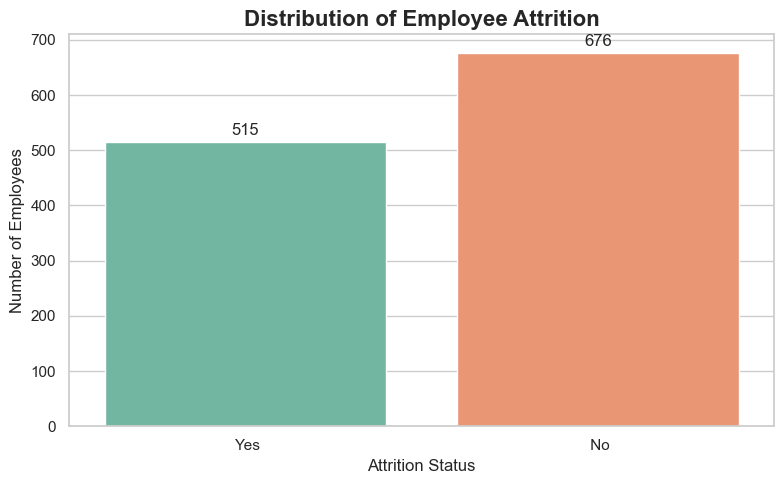

In [5]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Attrition', palette='Set2')
plt.title('Distribution of Employee Attrition', fontsize=16, fontweight='bold')
plt.ylabel('Number of Employees')
plt.xlabel('Attrition Status')

# Add bar labels
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig('../figures/01_attrition_distribution.png', dpi=300)
plt.show()

## 3. Bivariate Analysis
Now we will explore the relationship between `Attrition` and other key variables like `Gender`, `Department`, `Age`, and `Job_Satisfaction`.

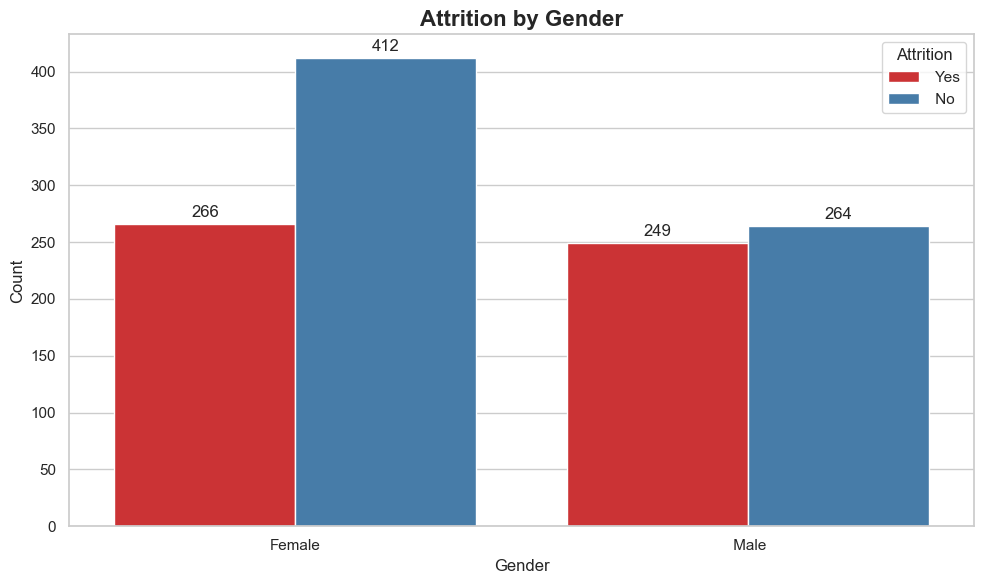

In [6]:
# 1. Gender vs Attrition
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Gender', hue='Attrition', palette='Set1')
plt.title('Attrition by Gender', fontsize=16, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Gender')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig('../figures/02_attrition_by_gender.png', dpi=300)
plt.show()

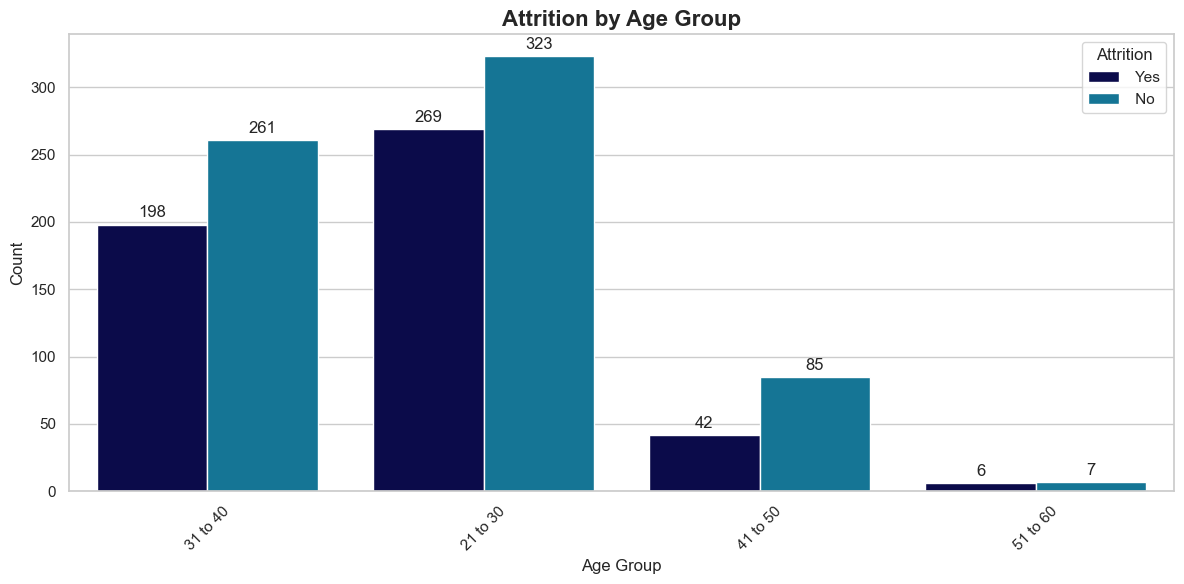

In [7]:
# 2. Age Group vs Attrition
plt.figure(figsize=(12, 6))
# Clean age column values just in case
df['Age'] = df['Age'].astype(str).str.strip()
ax = sns.countplot(data=df, x='Age', hue='Attrition', palette='ocean')
plt.title('Attrition by Age Group', fontsize=16, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Age Group')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig('../figures/03_attrition_by_age.png', dpi=300)
plt.show()

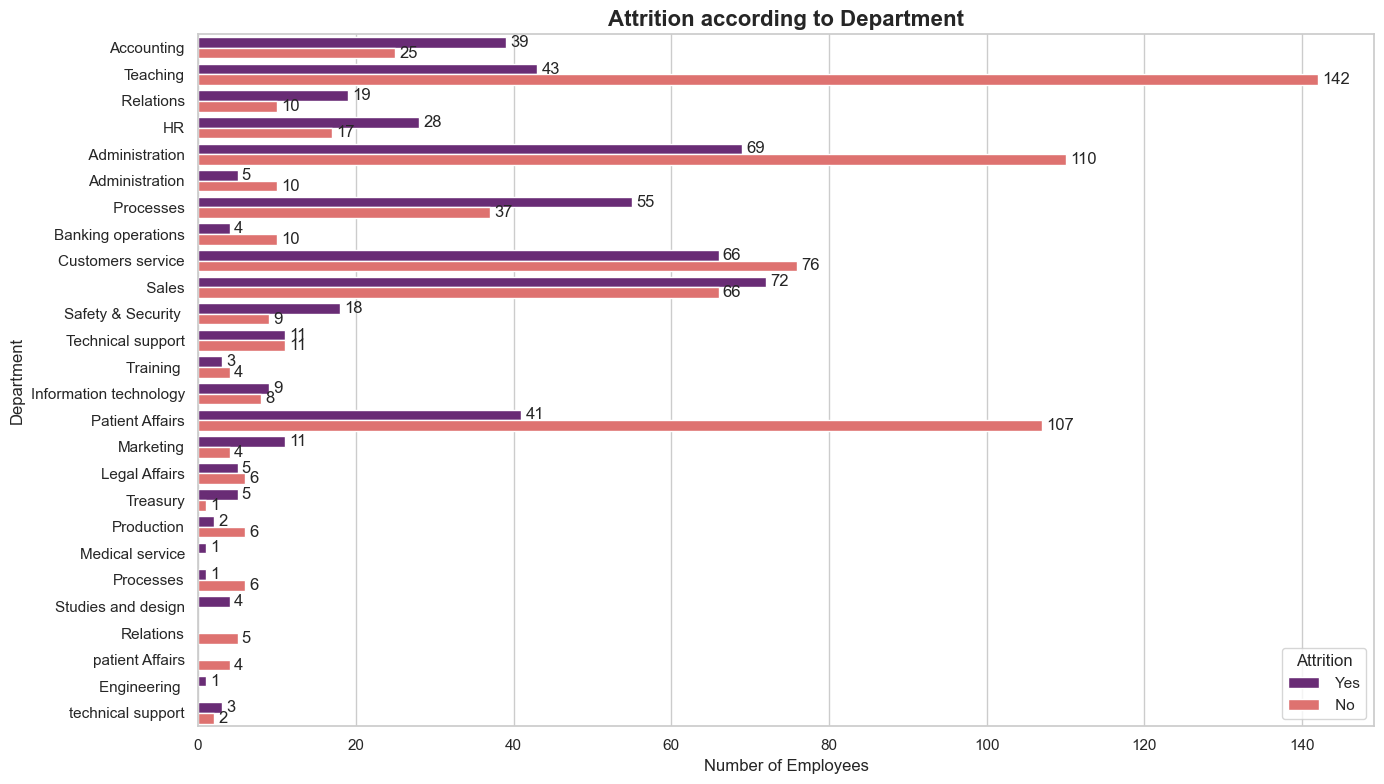

In [8]:
# 3. Department vs Attrition
plt.figure(figsize=(14, 8))
ax = sns.countplot(data=df, y='Department', hue='Attrition', palette='magma')
plt.title('Attrition according to Department', fontsize=16, fontweight='bold')
plt.ylabel('Department', fontsize=12)
plt.xlabel('Number of Employees', fontsize=12)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig('../figures/04_attrition_by_department.png', dpi=300)
plt.show()

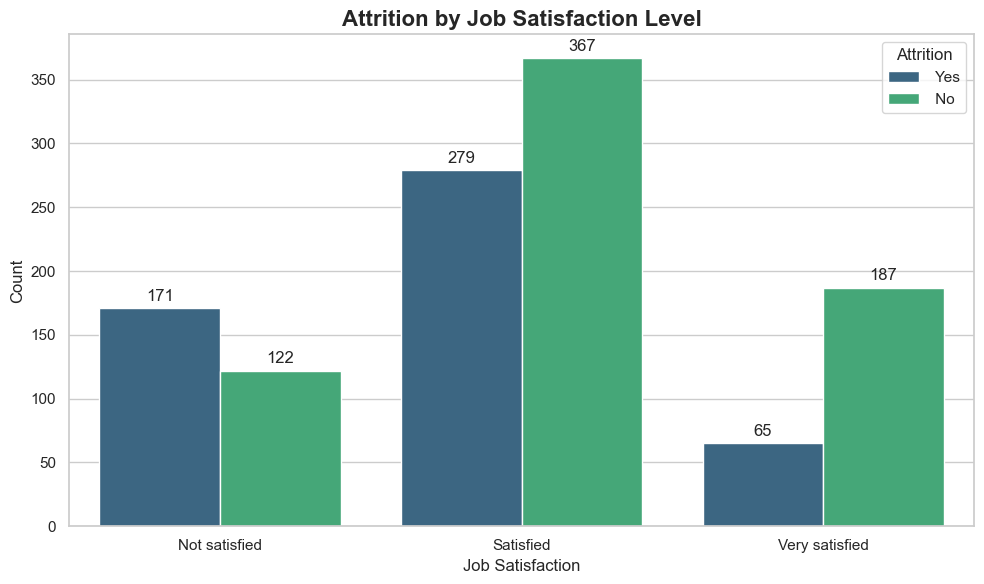

In [9]:
# 4. Job Satisfaction vs Attrition
plt.figure(figsize=(10, 6))
df['Job_Satisfaction'] = df['Job_Satisfaction'].astype(str).str.strip()
ax = sns.countplot(data=df, x='Job_Satisfaction', hue='Attrition', palette='viridis')
plt.title('Attrition by Job Satisfaction Level', fontsize=16, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Job Satisfaction')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig('../figures/05_attrition_by_job_satisfaction.png', dpi=300)
plt.show()

## 4. Work-Life Factors and Engagement
Exploring variables such as `Work_Live_Balance`, `Distance_to_work`, and `Job_Engagement`.

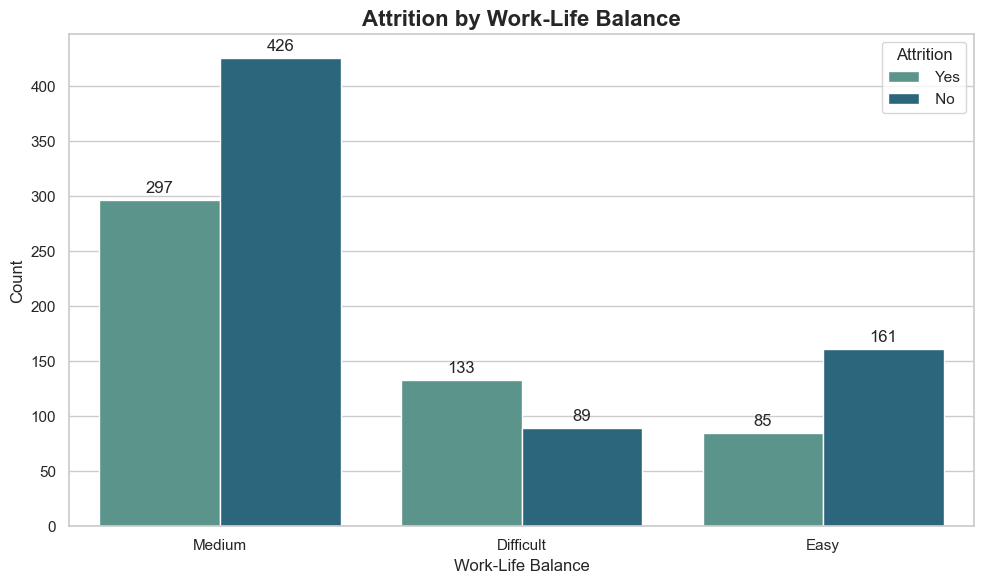

In [10]:
# Work Life Balance
plt.figure(figsize=(10, 6))
df['Work_Live_Balance'] = df['Work_Live_Balance'].astype(str).str.strip()
ax = sns.countplot(data=df, x='Work_Live_Balance', hue='Attrition', palette='crest')
plt.title('Attrition by Work-Life Balance', fontsize=16, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Work-Life Balance')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig('../figures/06_attrition_by_work_life_balance.png', dpi=300)
plt.show()

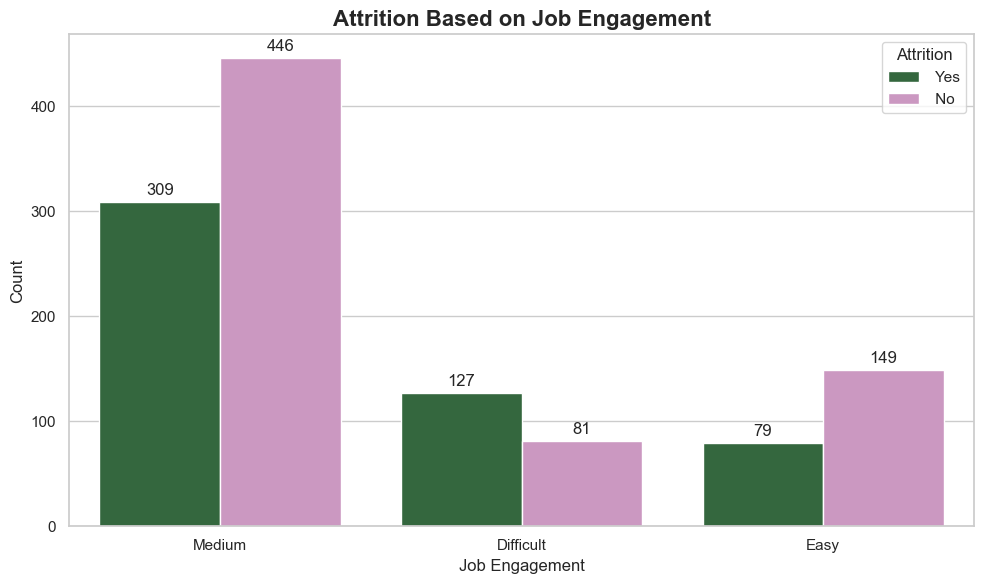

In [11]:
# Job Engagement
plt.figure(figsize=(10, 6))
df['Job_Engagement'] = df['Job_Engagement'].astype(str).str.strip()
ax = sns.countplot(data=df, x='Job_Engagement', hue='Attrition', palette='cubehelix')
plt.title('Attrition Based on Job Engagement', fontsize=16, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Job Engagement')

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.savefig('../figures/07_attrition_by_engagement.png', dpi=300)
plt.show()

## 5. Summary and Conclusion
- **Significant factors:** Job Satisfaction, Work-Life Balance, and Department play vital roles in attrition rates.
- **Trend Analysis:** Younger age groups and those with difficult Work-Life balance tend to have a higher ratio of attrition compared to their peers.

All visualizations have been successfully exported to the `figures/` directory.